In [19]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 309.3 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/8.3 MB 309.3 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/8.3 MB 309.3 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/8.3 MB 309.3 kB/s eta 0:00:2


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing

In [3]:
df=pd.read_csv("kc_house_filtered.csv")
df.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition
0,221900.0,3,1.00,1180,1.0,0,1955,3
1,538000.0,3,2.25,2570,2.0,0,1951,3
2,180000.0,2,1.00,770,1.0,0,1933,3
3,604000.0,4,3.00,1960,1.0,0,1965,5
4,510000.0,3,2.00,1680,1.0,0,1987,3


In [4]:
df.isnull().sum()

price          0
bedrooms       0
bathrooms      0
sqft_living    0
floors         0
waterfront     0
yr_built       0
condition      0
dtype: int64

<Axes: ylabel='sqft_living'>

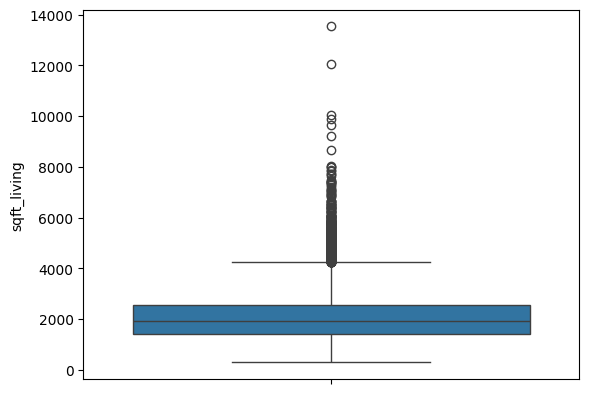

In [5]:
#Check outliers in the data using boxplot
sns.boxplot(data=df,y="sqft_living")

In [6]:
# Outliers handling
def find_caps(col_data):
    Q1=col_data.quantile(0.25)
    Q3=col_data.quantile(0.75)
    IQR=Q3-Q1
    lower_cap=Q1-1.5*IQR
    upper_cap=Q3+1.5*IQR
    return lower_cap,upper_cap
columns=["price","sqft_living","bedrooms"]
for col in columns:
    lower,upper=find_caps(df[col])
    outliers_count=((df[col]<lower) | (df[col]>upper)).sum()# gives sum of values greater than upper or less than lower(hence outliers)
    #clip the values to stay between lower and upper
    df[col]=df[col].clip(lower=lower,upper=upper)# give value lower to those less than lower and upper to values greater than upper
    print(f"""Capped {outliers_count} outliers in '{col}'.
          New range:{df[col].min()} to {df[col].max()}""")

Capped 1146 outliers in 'price'.
          New range:75000.0 to 1129575.0
Capped 572 outliers in 'sqft_living'.
          New range:290.0 to 4234.5
Capped 546 outliers in 'bedrooms'.
          New range:1.5 to 5.5


<Axes: ylabel='sqft_living'>

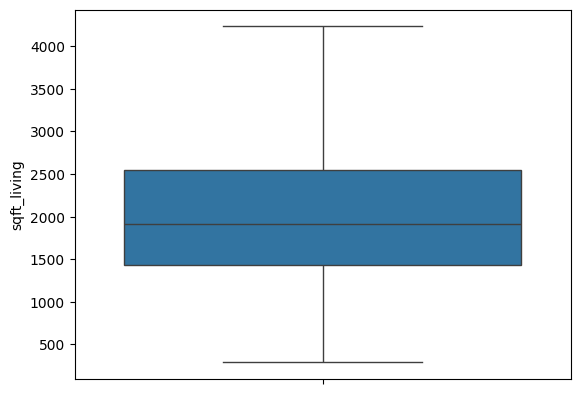

In [7]:
sns.boxplot(data=df,y="sqft_living")

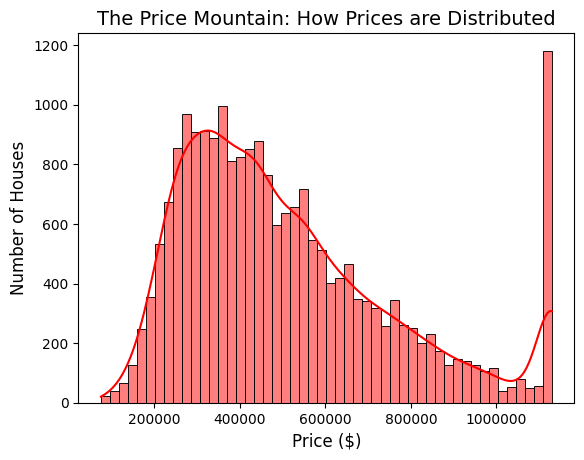

In [8]:
#Price histplot will change and will not be skewed
sns.histplot(data=df,x="price",kde=True,bins=50,color="red")
plt.title("The Price Mountain: How Prices are Distributed",fontsize=14)
plt.xlabel("Price ($)",fontsize=12)
plt.ticklabel_format(style="plain",axis="x")
plt.ylabel("Number of Houses",fontsize=12)
plt.show()

In [9]:
# Feature Scaling (important because ai model thinks that greater range features are imp. and lower range features are less imp.)
# Two types: 1.MinMaxScaler(0 to 1 scaling)  2.StandardScaler(Average of data is 0 and standard deviation is 1 (range 1 to -1))
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#MinMax scale
minmax_scalar=MinMaxScaler() #call object
df["Scaled_size"]=minmax_scalar.fit_transform(df[["sqft_living"]])

#std scalar
std_scalar=StandardScaler()
df["Year_Scaled"]=std_scalar.fit_transform(df[['yr_built']])
print("Scaled values preview:")
df

Scaled values preview:


,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition,Scaled_size,Year_Scaled
0,221900.0,3.0,1.00,1180.0,1.0,0,1955,3,0.225631,-0.544898
1,538000.0,3.0,2.25,2570.0,2.0,0,1951,3,0.578020,-0.681079
2,180000.0,2.0,1.00,770.0,1.0,0,1933,3,0.121688,-1.293892
3,604000.0,4.0,3.00,1960.0,1.0,0,1965,5,0.423374,-0.204446
4,510000.0,3.0,2.00,1680.0,1.0,0,1987,3,0.352389,0.544548
...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,2009,3,0.314362,1.293542
21609,400000.0,4.0,2.50,2310.0,2.0,0,2014,3,0.512105,1.463768
21610,402101.0,2.0,0.75,1020.0,2.0,0,2009,3,0.185068,1.293542
21611,400000.0,3.0,2.50,1600.0,2.0,0,2004,3,0.332108,1.123316


In [10]:
# Translating words to numbers (One-Hot Encoding)
np.random.seed(42)
neighborhoods=['Budget','Mid-Range','Premium']
df['Neighborhood']=np.random.choice(neighborhoods,size=len(df))
print("Neighborhood tiers before encoding:")
print(df['Neighborhood'].value_counts())

#One-Hot Encoding using pd.get_dummies
df_encoded=pd.get_dummies(df,columns=['Neighborhood'],prefix="Loc",dtype=int)# if prefix not given then will write Neighborhood as prefix
print("Columns after One-Hot Encoding:")
df_encoded


Neighborhood tiers before encoding:
Neighborhood
Budget       7240
Mid-Range    7223
Premium      7150
Name: count, dtype: int64
Columns after One-Hot Encoding:


,price,bedrooms,bathrooms,sqft_living,floors,waterfront,yr_built,condition,Scaled_size,Year_Scaled,Loc_Budget,Loc_Mid-Range,Loc_Premium
0,221900.0,3.0,1.00,1180.0,1.0,0,1955,3,0.225631,-0.544898,0,0,1
1,538000.0,3.0,2.25,2570.0,2.0,0,1951,3,0.578020,-0.681079,1,0,0
2,180000.0,2.0,1.00,770.0,1.0,0,1933,3,0.121688,-1.293892,0,0,1
3,604000.0,4.0,3.00,1960.0,1.0,0,1965,5,0.423374,-0.204446,0,0,1
4,510000.0,3.0,2.00,1680.0,1.0,0,1987,3,0.352389,0.544548,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,3.0,0,2009,3,0.314362,1.293542,0,0,1
21609,400000.0,4.0,2.50,2310.0,2.0,0,2014,3,0.512105,1.463768,0,0,1
21610,402101.0,2.0,0.75,1020.0,2.0,0,2009,3,0.185068,1.293542,1,0,0
21611,400000.0,3.0,2.50,1600.0,2.0,0,2004,3,0.332108,1.123316,1,0,0


In [12]:
#Pick our only final and cleaned columns
final_cols=['price','bedrooms','bathrooms','Scaled_size','floors','waterfront','sqft_living','condition','Loc_Budget','Loc_Mid-Range','Loc_Premium']
df_final=df_encoded[final_cols]
df_final.to_csv('kc_house_preprocessed.csv',index=False)